Aqui estamos fazendo as importações para contruir nossos graficos, treinarmos a IA e pegar informações do nosso arquivo em csv 


In [ ]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import sys
!{sys.executable} -m pip install imbalanced-learn


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


Aqui estamos traqzendo a quantidade linhas e colunas 

In [2]:
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')


df.shape


(7043, 21)

aqui estamos trazendo todas as nossas infromações do dataset

In [3]:
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Aqui estamos trazendo as informações do dataset

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

#Aqui estamos peganado os valore de cancelamento 

In [ ]:
df['Churn'].value_counts()


Churn
No     5174
Yes    1869
Name: count, dtype: int64

Parte 2


#Aqui vamos usar a qualidade dos dados
#Aqui mostra o total de valores nulos que cada tabela trás

In [ ]:

nulos = df.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else"Nenhum, valor nulo encontrado")

Nenhum, valor nulo encontrado


#valores duplicasdos
#trouxemos todos os valores duplicados

In [ ]:
dupli = df.duplicated().sum()
print(f"Linhas dupliucadas: {dupli} " if dupli > 0 else "Nenhum valor duplicado encontrado")
#trouxemos todos os valores duplicados


Nenhum valor duplicado encontrado


Aqui estamos confirindo se dados estão corretos ou incorretos

In [33]:
print(" TIPOS DE DADOS ")
for col in df.columns:
    print(f"{col:20} | tipo: {str(df[col].dtype):10} | exemplo: {df[col].iloc[0]}")

print("\n COLUNAS QUE DEVERIAM SER NÚMERO ")
for col in df.select_dtypes(include=['object', 'str']).columns:
    try:
        pd.to_numeric(df[col])
        print(f" {col} está como texto mas poderia ser número!")
    except:
        pass
        print("Nenhuma encontrada")

 TIPOS DE DADOS 
customerID           | tipo: str        | exemplo: 7590-VHVEG
gender               | tipo: str        | exemplo: Female
SeniorCitizen        | tipo: int64      | exemplo: 0
Partner              | tipo: str        | exemplo: Yes
Dependents           | tipo: str        | exemplo: No
tenure               | tipo: int64      | exemplo: 1
PhoneService         | tipo: str        | exemplo: No
MultipleLines        | tipo: str        | exemplo: No phone service
InternetService      | tipo: str        | exemplo: DSL
OnlineSecurity       | tipo: str        | exemplo: No
OnlineBackup         | tipo: str        | exemplo: Yes
DeviceProtection     | tipo: str        | exemplo: No
TechSupport          | tipo: str        | exemplo: No
StreamingTV          | tipo: str        | exemplo: No
StreamingMovies      | tipo: str        | exemplo: No
Contract             | tipo: str        | exemplo: Month-to-month
PaperlessBilling     | tipo: str        | exemplo: Yes
PaymentMethod        | ti

Aqui estamos coferindo se temos dados inconsientes no qual não fazem sentido

In [36]:
print(" DADOS INCONSISTENTES ")
for col in df.select_dtypes(include=['object', 'str']).columns:
    valores = df[col].unique()
    tem_inconsistente = any(str(v).strip().lower() in ['???', 'n/a', 'na', 'none', ''] for v in valores)
    if tem_inconsistente:
        print(f"{col} tem dados inconsistentes: {valores}")
    else:
        print(f"{col} → OK")

 DADOS INCONSISTENTES 
customerID → OK
gender → OK
Partner → OK
Dependents → OK
PhoneService → OK
MultipleLines → OK
InternetService → OK
OnlineSecurity → OK
OnlineBackup → OK
DeviceProtection → OK
TechSupport → OK
StreamingTV → OK
StreamingMovies → OK
Contract → OK
PaperlessBilling → OK
PaymentMethod → OK
TotalCharges tem dados inconsistentes: <StringArray>
[  '29.85',  '1889.5',  '108.15', '1840.75',  '151.65',   '820.5',  '1949.4',
   '301.9', '3046.05', '3487.95',
 ...
 '2625.25', '6886.25',  '1495.1',   '743.3',  '1419.4',  '1990.5',  '7362.9',
  '346.45',   '306.6',  '6844.5']
Length: 6531, dtype: str
Churn → OK


aqui o certo TotalCharges eles deveriam ser numeros mas estavam como string

Distribuição de dados

DISTRIBUIÇÃO DAS VARIÁVEIS NUMÉRICAS 


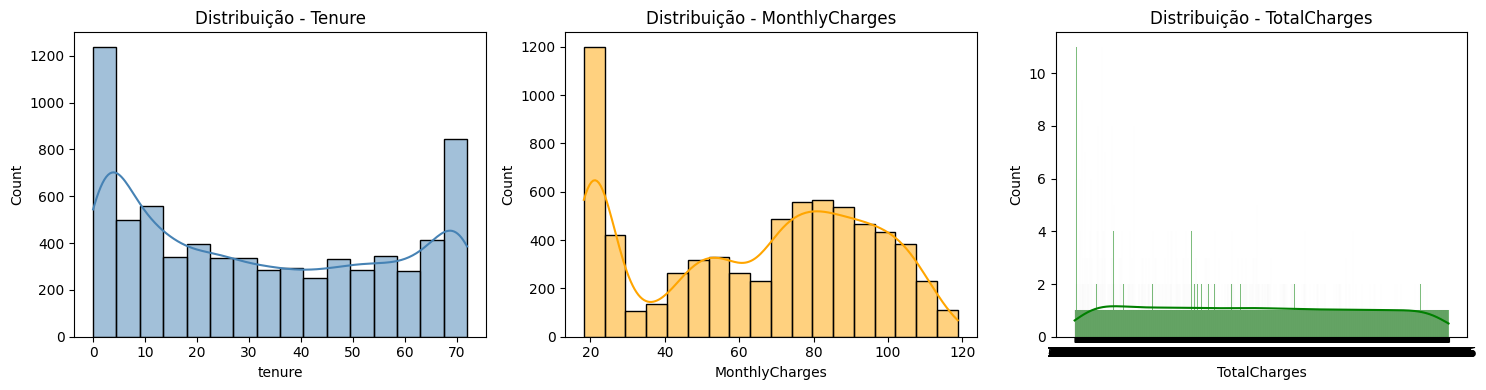

In [38]:
print("DISTRIBUIÇÃO DAS VARIÁVEIS NUMÉRICAS ")
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df['tenure'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribuição - Tenure')

sns.histplot(df['MonthlyCharges'], kde=True, ax=axes[1], color='orange')
axes[1].set_title('Distribuição - MonthlyCharges')

sns.histplot(df['TotalCharges'], kde=True, ax=axes[2], color='green')
axes[2].set_title('Distribuição - TotalCharges')

plt.tight_layout()
plt.show()

Baseado nós tres graficos o priemiro quase apresenta uma concentração, o segundo ele já não apresentão muto pois ele tem bastante elevaçãoes e algumas decaidas e o mais que se mantém em concentração é o terceiro, pois é bem raro de apresentar diferenças masa ele se mantem em concentração basicamente.

Na questão de extremos o unico que apresneta uma maior é o terceiro gráfico no qual ele passa muito valor do seu eixo y ja os outro dois o primeiro passa por muito pouco mas o segundo fica na no limite.

OUTLIERS 


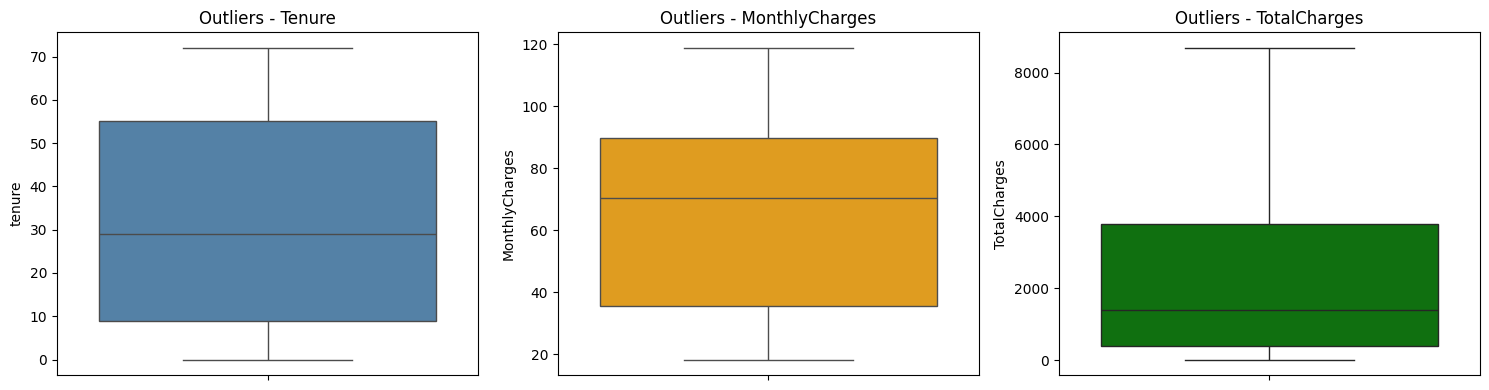

In [43]:
print("OUTLIERS ")
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')


fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(y=df['tenure'], ax=axes[0], color='steelblue')
axes[0].set_title('Outliers - Tenure')

sns.boxplot(y=df['MonthlyCharges'], ax=axes[1], color='orange')
axes[1].set_title('Outliers - MonthlyCharges')

sns.boxplot(y=df['TotalCharges'], ax=axes[2], color='green')
axes[2].set_title('Outliers - TotalCharges')

plt.tight_layout()
plt.show()

nós graficos de outliers podemos ter a noção da média baseada nos quadrados e a mediana que representada dentro do quadrado 

In [40]:
print("RESUMO ESTATÍSTICO")
df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe()

RESUMO ESTATÍSTICO


,tenure,MonthlyCharges
count,7043.000000,7043.000000
mean,32.371149,64.761692
std,24.559481,30.090047
min,0.000000,18.250000
25%,9.000000,35.500000
50%,29.000000,70.350000
75%,55.000000,89.850000
max,72.000000,118.750000


No grafico azul -> vemos que ele não apresenta outliers por que ele se mantem entre 0 até 70 
No grafico laranja -> podemos ver que ele mantem também entre 20 e 120 
No grafico verde  -> podemos ver que ele mantem também entre 0 e 9000 
resumindo nenhum passou do limite ou ficou a baixo


In [62]:
print("Relação de variáveis")

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

calCorreColumns = df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr()

#Criando um mapa de calor para fazermos as relações 
fig = px.imshow(
    calCorreColumns,
    text_auto=True,
    title="Gráfico de correlação entre variáveis",
    color_continuous_scale='RdBu_r'
)

fig.show()



Relação de variáveis


PODEMOS analisar nesse gráfico que Teenure com TotalChanges ela tem uma conecção forte e segunda que tem essa coneção é a MonthlyCharges com TotalChanges no qual elas apresentam uma conecção mediana entre todas, então resumindo a TotalChanges influencia a conecções. E nesse caso existe um padrão.

In [74]:
print("Quem cancela mais")

fig = px.histogram(
    df,
    x="Contract",
    color='Churn',
    barmode='group',
    title='Contrato vs Cancelamento',
    color_discrete_sequence=['#2ecc71', '#e74c3c']
)

fig.show()

Quem cancela mais


Baseado nos cancelamentos podemos ver que em mes a mes tem muito cancelamentos comparado aos outros. por conta que o cliente pode cancelar o contrato a qualquer momento nãó é igual a uma fidelidade

● Relação com o alvo (Churn)


In [73]:
print("Cancelamento por tempo de contrato")

fig = px.box(
    df,
    x='Churn',
    y='tenure',
    color='Churn',
    title='Tempo de Contrato (Tenure) vs Cancelamento (Churn)',
    color_discrete_sequence=['#2ecc71', '#e74c3c']
)
fig.show()

Cancelamento por tempo de contrato


Baseaso nesse gráfico podemos ter uma noção que quando maior o tempo do contrato não teremos tantas perdas

In [76]:
print("Cancelamento por mensalidade")


fig = px.box(
    df,
    x='Churn',
    y='MonthlyCharges',
    color='Churn',
    title='Mensalidade vs Churn',
    color_discrete_sequence=['#2ecc71', '#e74c3c']
)
fig.show()

Cancelamento por mensalidade


Baseado no grafico por mensalidade tempos mais cancelamentos, porque quantos mais a mensalidade mais cancelamento tempos 

● Padrões e tendências


In [11]:
print("Perfil de cliente")
fig = px.histogram(
    df,
    x='InternetService',
    color='Churn',
    barmode='group',
    title='Tipo de Serviço de Internet vs Churn',
    color_discrete_sequence=['#2ecc71', '#e74c3c']
)
fig.show()

Perfil de cliente


In [14]:
print("comportamento repetido")

# Perfil mais comum de quem cancela
cancelou = df[df['Churn'] == 'Yes']

print("\nContrato mais comum de quem cancela:")
print(cancelou['Contract'].value_counts())

print("\nInternet mais comum de quem cancela:")
print(cancelou['InternetService'].value_counts())

print("\nPagamento mais comum de quem cancela:")
print(cancelou['PaymentMethod'].value_counts())

print("\nTem suporte técnico?")
print(cancelou['TechSupport'].value_counts())

comportamento repetido

Contrato mais comum de quem cancela:
Contract
Month-to-month    1655
One year           166
Two year            48
Name: count, dtype: int64

Internet mais comum de quem cancela:
InternetService
Fiber optic    1297
DSL             459
No              113
Name: count, dtype: int64

Pagamento mais comum de quem cancela:
PaymentMethod
Electronic check             1071
Mailed check                  308
Bank transfer (automatic)     258
Credit card (automatic)       232
Name: count, dtype: int64

Tem suporte técnico?
TechSupport
No                     1446
Yes                     310
No internet service     113
Name: count, dtype: int64


In [17]:
print("Variavies importantes")

coluns = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport', 'Partner', 'Dependents', 'SeniorCitizen']

for col in coluns:
    taxa = df.groupby(col)['Churn'].value_counts(normalize=True).unstack()
    print(f'\n {col}')
    print(taxa)

Variavies importantes

 Contract
Churn                 No       Yes
Contract                          
Month-to-month  0.572903  0.427097
One year        0.887305  0.112695
Two year        0.971681  0.028319

 InternetService
Churn                  No       Yes
InternetService                    
DSL              0.810409  0.189591
Fiber optic      0.581072  0.418928
No               0.925950  0.074050

 PaymentMethod
Churn                            No       Yes
PaymentMethod                                
Bank transfer (automatic)  0.832902  0.167098
Credit card (automatic)    0.847569  0.152431
Electronic check           0.547146  0.452854
Mailed check               0.808933  0.191067

 TechSupport
Churn                      No       Yes
TechSupport                            
No                   0.583645  0.416355
No internet service  0.925950  0.074050
Yes                  0.848337  0.151663

 Partner
Churn          No       Yes
Partner                    
No       0.670420  0.3

Pré-processamento


In [23]:
# ## Realizar limpeza dos dados identificados na EDA
# df.drop(['customerID', 'gender', 'PhoneService'], axis=1, inplace=True, errors='ignore')


# #Tratar valores nulos
# df.dropna(inplace=True)

# #Corrrigir tipos de dados
# df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')



# 1. Remover colunas irrelevantes
df.drop(['customerID', 'gender', 'PhoneService'], axis=1, inplace=True, errors='ignore')
print("✅ Colunas irrelevantes removidas")

# 2. Corrigir TotalCharges para número
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("✅ TotalCharges convertido para número")

# 3. Remover linhas nulas geradas
df.dropna(inplace=True)
print(f"✅ Valores nulos removidos")

# 4. Converter Churn para 0 e 1
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print("✅ Churn convertido para 0 e 1")

# 5. Converter variáveis categóricas
df = pd.get_dummies(df, drop_first=True)
print("✅ Variáveis categóricas convertidas")

print(f"\nDataset final: {df.shape[0]} linhas e {df.shape[1]} colunas")
df.head()




✅ Colunas irrelevantes removidas
✅ TotalCharges convertido para número
✅ Valores nulos removidos


✅ Churn convertido para 0 e 1
✅ Variáveis categóricas convertidas

Dataset final: 7032 linhas e 29 colunas


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,Partner_Yes,Dependents_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,NaN,True,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,NaN,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,NaN,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,NaN,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,NaN,False,False,False,False,True,...,False,False,False,False,False,False,True,False,True,False


Modelagem, Treinamento e Comparação


In [21]:
from sklearn.model_selection import train_test_split

# Definindo features e target (já pré-processados no df)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Criando treino/teste para evitar NameError pelo X_train/y_train não definidos
X_train, X_test, y_train, y_test = train_test_split(
	X, y, test_size=0.25, random_state=42, stratify=y
)

# Modelo 1 - Regressão Logística
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

# Modelo 2 - Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

# Modelo 3 - Árvore de Decisão
dt = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)

print("✅ Modelos treinados com balanceamento!")

c:\Users\Usuario\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


✅ Modelos treinados com balanceamento!


Comparação

In [24]:
modelos = {
    'Regressão Logística': pred_lr,
    'Random Forest': pred_rf,
    'Árvore de Decisão': pred_dt
}

for nome, pred in modelos.items():
    print(f"\n=== {nome} ===")
    print(f"Acurácia:  {accuracy_score(y_test, pred):.2f}")
    print(f"Precisão:  {precision_score(y_test, pred):.2f}")
    print(f"Recall:    {recall_score(y_test, pred):.2f}")
    print(f"F1 Score:  {f1_score(y_test, pred):.2f}")


=== Regressão Logística ===
Acurácia:  0.73
Precisão:  0.50
Recall:    0.80
F1 Score:  0.61

=== Random Forest ===
Acurácia:  0.78
Precisão:  0.61
Recall:    0.47
F1 Score:  0.53

=== Árvore de Decisão ===
Acurácia:  0.74
Precisão:  0.52
Recall:    0.49
F1 Score:  0.50


Matriz de confusão

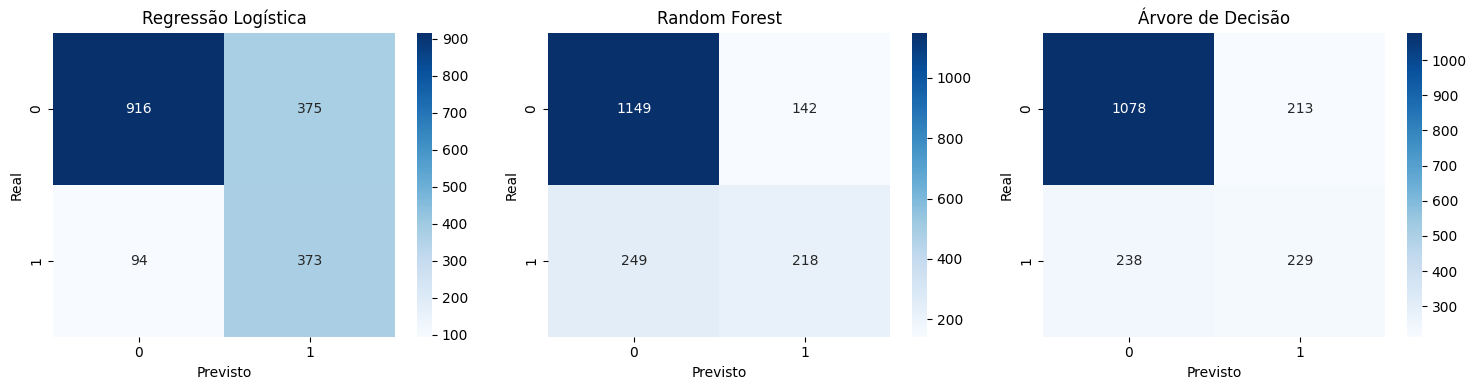

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

modelos_map = {
    'Regressão Logística': pred_lr,
    'Random Forest': pred_rf,
    'Árvore de Decisão': pred_dt
}

for ax, (nome, pred) in zip(axes, modelos_map.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(nome)
    ax.set_xlabel('Previsto')
    ax.set_ylabel('Real')

plt.tight_layout()
plt.show()


In [27]:
import joblib

# Salvar o modelo escolhido (Regressão Logística)
joblib.dump(lr, '../model/model.pkl')

# Salvar as colunas usadas no treino (importante para a API!)
joblib.dump(X.columns.tolist(), '../model/features.pkl')

print("✅ Modelo salvo em ../model/model.pkl")
print("✅ Features salvas em ../model/features.pkl")

✅ Modelo salvo em ../model/model.pkl
✅ Features salvas em ../model/features.pkl
